# Frequency Preprocessing Check

`cv_eda_traditional.ipynb`에서 사용한 주파수 지표를 그대로 가져와, 모든 split에 공통 Gaussian blur를 적용했을 때 `train`과 `dev/test`의 주파수 분포 차이가 얼마나 줄어드는지 확인합니다.

핵심 목표
- `fft_high_freq_ratio`, `laplacian_var`, `noise_residual_std`를 기준으로 split 간 차이 측정
- `sigma` sweep으로 공통 blur 강도별 domain gap 변화를 비교
- 가장 나은 `sigma`를 기준으로 분포 시각화
- 약 10개 샘플을 원본과 blur 결과로 비교

In [1]:
# Setup: import와 경로, 기본 옵션을 정의하는 셀
from __future__ import annotations

import os
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

import cv2
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

DATA_DIR = ROOT / 'data'
OUT_DIR = ROOT / 'outputs' / 'eda_preprocessing'
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
RNG = np.random.default_rng(RANDOM_STATE)
SPLITS = ['train', 'dev', 'test']
VIEWS = ['front', 'top']
SIGMAS = [0.0, 0.5, 1.0, 1.5, 2.0]
MAX_SAMPLES_PER_SPLIT = 150

print({
    'root': str(ROOT),
    'data_dir': str(DATA_DIR),
    'sigmas': SIGMAS,
    'max_samples_per_split': MAX_SAMPLES_PER_SPLIT,
})

{'root': '/media/hdd0/whyz/structure-stability', 'data_dir': '/media/hdd0/whyz/structure-stability/data', 'sigmas': [0.0, 0.5, 1.0, 1.5, 2.0], 'max_samples_per_split': 150}


In [2]:
# Catalog: split별 이미지 메타데이터를 수집하는 셀
def build_image_catalog() -> pd.DataFrame:
    rows = []
    for split in SPLITS:
        split_dir = DATA_DIR / split
        if not split_dir.exists():
            continue
        for sample_dir in sorted([p for p in split_dir.iterdir() if p.is_dir()]):
            for view in VIEWS:
                image_path = sample_dir / f'{view}.png'
                if image_path.exists():
                    rows.append({
                        'split': split,
                        'sample_id': sample_dir.name,
                        'view': view,
                        'image_path': image_path,
                    })
    return pd.DataFrame(rows)


def sample_image_rows(df: pd.DataFrame, max_samples_per_split: int | None = MAX_SAMPLES_PER_SPLIT) -> pd.DataFrame:
    if max_samples_per_split is None:
        return df.copy().reset_index(drop=True)

    keep_ids = []
    for split, part in df.groupby('split'):
        sample_ids = np.array(sorted(part['sample_id'].unique()))
        take = min(max_samples_per_split, len(sample_ids))
        chosen = RNG.choice(sample_ids, size=take, replace=False)
        keep_ids.extend((split, sample_id) for sample_id in chosen)

    keep_df = pd.DataFrame(keep_ids, columns=['split', 'sample_id'])
    sampled = df.merge(keep_df, on=['split', 'sample_id'], how='inner')
    return sampled.sort_values(['split', 'sample_id', 'view']).reset_index(drop=True)


image_df = build_image_catalog()
sampled_images = sample_image_rows(image_df, MAX_SAMPLES_PER_SPLIT)

display(image_df.groupby(['split', 'view']).size().rename('images').reset_index())
display(sampled_images.groupby(['split', 'view']).size().rename('sampled_images').reset_index())

,split,view,images
0,dev,front,100
1,dev,top,100
2,test,front,1000
3,test,top,1000
4,train,front,1000
5,train,top,1000


,split,view,sampled_images
0,dev,front,100
1,dev,top,100
2,test,front,150
3,test,top,150
4,train,front,150
5,train,top,150


In [3]:
# Frequency functions: blur와 주파수 feature를 정의하는 셀
def read_rgb(path: Path) -> np.ndarray:
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


def to_gray(rgb: np.ndarray) -> np.ndarray:
    return cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)


def apply_gaussian_blur_rgb(rgb: np.ndarray, sigma: float) -> np.ndarray:
    if sigma <= 0:
        return rgb.copy()
    return cv2.GaussianBlur(rgb, ksize=(0, 0), sigmaX=sigma, sigmaY=sigma, borderType=cv2.BORDER_REFLECT)


def fft_high_freq_ratio(gray: np.ndarray, center_frac: float = 0.18) -> float:
    gray_f = gray.astype(np.float32)
    fft = np.fft.fftshift(np.fft.fft2(gray_f))
    mag = np.abs(fft)
    h, w = gray.shape
    cy, cx = h // 2, w // 2
    ry, rx = int(h * center_frac / 2), int(w * center_frac / 2)
    low_mask = np.zeros_like(gray_f, dtype=bool)
    low_mask[max(0, cy - ry): min(h, cy + ry + 1), max(0, cx - rx): min(w, cx + rx + 1)] = True
    total = mag.sum() + 1e-6
    high = mag[~low_mask].sum()
    return float(high / total)


def estimate_structure_mask(rgb: np.ndarray) -> np.ndarray:
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    h, w = lab.shape[:2]
    border = np.concatenate([
        lab[:18].reshape(-1, 3),
        lab[-18:].reshape(-1, 3),
        lab[:, :18].reshape(-1, 3),
        lab[:, -18:].reshape(-1, 3),
    ], axis=0)
    center = np.median(border, axis=0)
    dist = np.linalg.norm(lab.astype(np.float32) - center.astype(np.float32), axis=2)
    thr = np.percentile(dist, 84)
    mask = (dist > thr).astype(np.uint8) * 255
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((9, 9), np.uint8))

    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask)
    if n_labels <= 1:
        return np.zeros((h, w), dtype=np.uint8)

    image_center = np.array([w / 2, h / 2])
    best_score = None
    best_idx = None
    for idx in range(1, n_labels):
        area = stats[idx, cv2.CC_STAT_AREA]
        if area < 80:
            continue
        x = stats[idx, cv2.CC_STAT_LEFT]
        y = stats[idx, cv2.CC_STAT_TOP]
        ww = stats[idx, cv2.CC_STAT_WIDTH]
        hh = stats[idx, cv2.CC_STAT_HEIGHT]
        centroid = np.array([x + ww / 2, y + hh / 2])
        center_penalty = np.linalg.norm((centroid - image_center) / np.array([w, h]))
        score = area - 4000 * center_penalty
        if best_score is None or score > best_score:
            best_score = score
            best_idx = idx

    out = np.zeros((h, w), dtype=np.uint8)
    if best_idx is not None:
        out[labels == best_idx] = 255
    return out


def extract_structure_only_image(rgb: np.ndarray, pad_frac: float = 0.08, min_size: int = 48) -> tuple[np.ndarray, np.ndarray]:
    mask = estimate_structure_mask(rgb)
    ys, xs = np.where(mask > 0)
    h, w = mask.shape
    if len(xs) == 0 or len(ys) == 0:
        return rgb.copy(), mask

    x0, x1 = xs.min(), xs.max() + 1
    y0, y1 = ys.min(), ys.max() + 1
    pad_x = max(int((x1 - x0) * pad_frac), 8)
    pad_y = max(int((y1 - y0) * pad_frac), 8)
    x0 = max(0, x0 - pad_x)
    y0 = max(0, y0 - pad_y)
    x1 = min(w, x1 + pad_x)
    y1 = min(h, y1 + pad_y)

    crop = rgb[y0:y1, x0:x1].copy()
    crop_mask = mask[y0:y1, x0:x1].copy()
    if crop.shape[0] < min_size or crop.shape[1] < min_size:
        return rgb.copy(), mask

    mask_bool = crop_mask > 0
    if not mask_bool.any():
        return crop, crop_mask

    structure_only = crop.copy()
    fill_rgb = np.median(crop[mask_bool], axis=0).astype(np.uint8)
    structure_only[~mask_bool] = fill_rgb
    return structure_only, crop_mask


def extract_frequency_features(rgb: np.ndarray) -> dict[str, float]:
    gray = to_gray(rgb)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    residual = gray.astype(np.float32) - blur.astype(np.float32)
    edges = cv2.Canny(blur, 60, 140)
    return {
        'fft_high_freq_ratio': fft_high_freq_ratio(gray),
        'laplacian_var': float(cv2.Laplacian(gray, cv2.CV_32F).var()),
        'noise_residual_std': float(residual.std()),
        'edge_density': float((edges > 0).mean()),
    }


def cdf_distance(a: np.ndarray, b: np.ndarray, n_grid: int = 512) -> float:
    a = np.asarray(a, dtype=np.float32)
    b = np.asarray(b, dtype=np.float32)
    lo = float(min(a.min(), b.min()))
    hi = float(max(a.max(), b.max()))
    grid = np.linspace(lo, hi, n_grid)
    cdf_a = np.searchsorted(np.sort(a), grid, side='right') / len(a)
    cdf_b = np.searchsorted(np.sort(b), grid, side='right') / len(b)
    return float(np.mean(np.abs(cdf_a - cdf_b)))

In [4]:
# Sigma sweep: 공통 blur 강도별 frequency feature를 추출하는 셀
feature_rows = []
for sigma in SIGMAS:
    desc = f'Frequency features | sigma={sigma}'
    for row in tqdm(list(sampled_images.itertuples(index=False)), desc=desc):
        rgb = read_rgb(Path(row.image_path))
        blurred_rgb = apply_gaussian_blur_rgb(rgb, sigma)
        freq_stats = extract_frequency_features(blurred_rgb)
        feature_rows.append({
            'sigma': sigma,
            'split': row.split,
            'sample_id': row.sample_id,
            'view': row.view,
            'image_path': Path(row.image_path),
            **freq_stats,
        })

freq_df = pd.DataFrame(feature_rows)
freq_path = OUT_DIR / 'frequency_blur_sweep.csv'
freq_df.to_csv(freq_path, index=False)
print('saved:', freq_path)
freq_df.head()

Frequency features | sigma=0.0:   0%|          | 0/800 [00:00<?, ?it/s]

Frequency features | sigma=0.5:   0%|          | 0/800 [00:00<?, ?it/s]

Frequency features | sigma=1.0:   0%|          | 0/800 [00:00<?, ?it/s]

Frequency features | sigma=1.5:   0%|          | 0/800 [00:00<?, ?it/s]

Frequency features | sigma=2.0:   0%|          | 0/800 [00:00<?, ?it/s]

saved: /media/hdd0/whyz/structure-stability/outputs/eda_preprocessing/frequency_blur_sweep.csv


,sigma,split,sample_id,view,image_path,fft_high_freq_ratio,laplacian_var,noise_residual_std,edge_density
0,0.0,dev,DEV_001,front,/media/hdd0/whyz/structure-stability/data/dev/...,0.637002,327.098755,5.252008,0.050720
1,0.0,dev,DEV_001,top,/media/hdd0/whyz/structure-stability/data/dev/...,0.615081,175.189026,3.681668,0.034173
2,0.0,dev,DEV_002,front,/media/hdd0/whyz/structure-stability/data/dev/...,0.653054,571.769470,6.555159,0.058316
3,0.0,dev,DEV_002,top,/media/hdd0/whyz/structure-stability/data/dev/...,0.591829,283.186249,5.020727,0.042107
4,0.0,dev,DEV_003,front,/media/hdd0/whyz/structure-stability/data/dev/...,0.627385,544.732727,6.683263,0.067362


In [5]:
# Distance summary: sigma별로 train과 dev/test의 분포 차이를 수치화하는 셀
metric_cols = ['fft_high_freq_ratio', 'laplacian_var', 'noise_residual_std']
distance_rows = []

for sigma in SIGMAS:
    sigma_df = freq_df.query('sigma == @sigma')
    for view in VIEWS:
        for metric in metric_cols:
            train_vals = sigma_df.query('split == "train" and view == @view')[metric].to_numpy()
            dev_vals = sigma_df.query('split == "dev" and view == @view')[metric].to_numpy()
            test_vals = sigma_df.query('split == "test" and view == @view')[metric].to_numpy()
            distance_rows.append({
                'sigma': sigma,
                'view': view,
                'metric': metric,
                'train_vs_dev': cdf_distance(train_vals, dev_vals),
                'train_vs_test': cdf_distance(train_vals, test_vals),
                'avg_gap': np.mean([
                    cdf_distance(train_vals, dev_vals),
                    cdf_distance(train_vals, test_vals),
                ]),
            })

distance_df = pd.DataFrame(distance_rows).round(4)
display(distance_df)

sigma_score_df = (
    distance_df.groupby('sigma')[['train_vs_dev', 'train_vs_test', 'avg_gap']]
    .mean()
    .round(4)
    .reset_index()
    .sort_values('avg_gap')
)
display(sigma_score_df)

best_sigma = float(sigma_score_df.iloc[0]['sigma'])
nonzero_sigma_score_df = sigma_score_df.query('sigma > 0').copy()
best_nonzero_sigma = float(nonzero_sigma_score_df.iloc[0]['sigma']) if len(nonzero_sigma_score_df) else best_sigma
print({'best_sigma': best_sigma, 'best_nonzero_sigma': best_nonzero_sigma})

,sigma,view,metric,train_vs_dev,train_vs_test,avg_gap
0,0.0,front,fft_high_freq_ratio,0.2882,0.2628,0.2755
1,0.0,front,laplacian_var,0.1668,0.2035,0.1852
2,0.0,front,noise_residual_std,0.2995,0.2960,0.2978
3,0.0,top,fft_high_freq_ratio,0.4663,0.4511,0.4587
4,0.0,top,laplacian_var,0.1512,0.1071,0.1291
5,0.0,top,noise_residual_std,0.0611,0.1078,0.0844
6,0.5,front,fft_high_freq_ratio,0.3063,0.2897,0.2980
7,0.5,front,laplacian_var,0.2613,0.2780,0.2696
8,0.5,front,noise_residual_std,0.3436,0.3562,0.3499
9,0.5,top,fft_high_freq_ratio,0.4405,0.4391,0.4398


,sigma,train_vs_dev,train_vs_test,avg_gap
0,0.0,0.2388,0.2380,0.2385
1,0.5,0.2577,0.2645,0.2611
3,1.5,0.2614,0.2711,0.2662
4,2.0,0.2965,0.2992,0.2979
2,1.0,0.2836,0.3232,0.3034


{'best_sigma': 0.0, 'best_nonzero_sigma': 0.5}


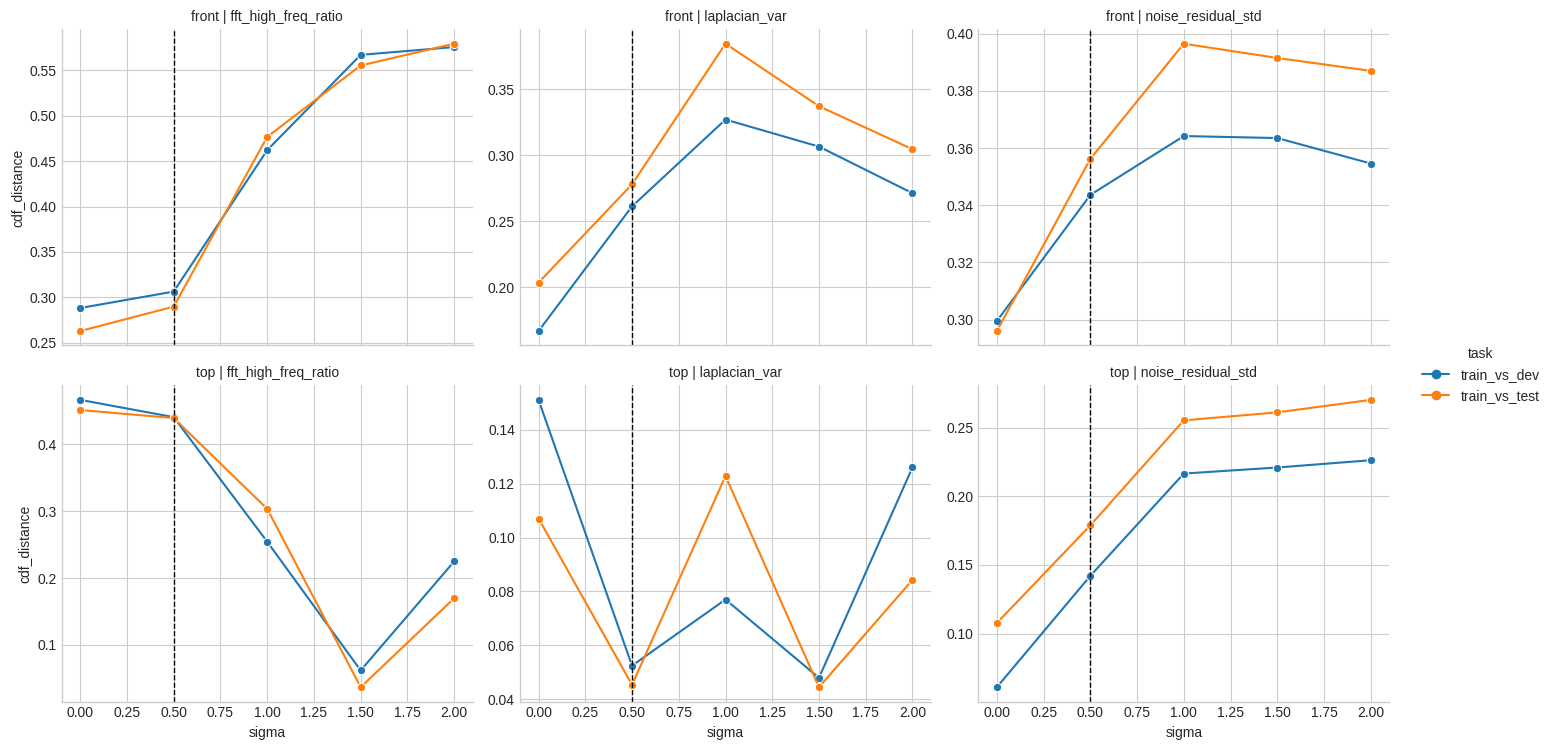

In [6]:
# Plot: sigma sweep에 따라 split gap이 어떻게 변하는지 보는 셀
plot_df = distance_df.melt(
    id_vars=['sigma', 'view', 'metric'],
    value_vars=['train_vs_dev', 'train_vs_test'],
    var_name='task',
    value_name='cdf_distance',
)

g = sns.relplot(
    data=plot_df,
    x='sigma',
    y='cdf_distance',
    hue='task',
    col='metric',
    row='view',
    kind='line',
    marker='o',
    facet_kws={'sharey': False},
    height=3.8,
    aspect=1.25,
)
for ax in g.axes.flat:
    ax.axvline(best_nonzero_sigma, color='black', linestyle='--', linewidth=1)
g.set_titles('{row_name} | {col_name}')
g.tight_layout()

fft_high_freq_ratio                 laplacian_var                    noise_residual_std                 edge_density                
                                          mean     std  median          mean      std    median               mean     std  median         mean     std  median
condition      split view                                                                                                                                      
blur_sigma_0.5 dev   front              0.5659  0.0098  0.5657      191.3229  36.4577  186.1789             4.4069  0.3924  4.3830       0.0553  0.0137  0.0554
                     top                0.5397  0.0144  0.5393       97.5265  19.7277   98.1156             3.1643  0.2836  3.1507       0.0356  0.0038  0.0362
               test  front              0.5640  0.0100  0.5625      184.3855  32.9662  181.3704             4.3480  0.3594  4.3423       0.0537  0.0122  0.0528
                     top                0.5367  0.0167  0.5385       91.3636  17.5812   88.4323             3.0864  0.2510  3.0709       0.0347  0.0040  0.0357
               train front              0.5451  0.0060  0.5456      233.9520  23.4272  236.9967             5.0199  0.1863  5.0381       0.0676  0.0031  0.0684
                     top                0.4757  0.0171  0.4719       95.0366  20.9937   92.0331             3.3922  0.2851  3.3685       0.0378  0.0016  0.0372
original       dev   front              0.6394  0.0110  0.6398      466.1731  99.8849  462.7603             5.9926  0.5532  5.9458       0.0628  0.0131  0.0632
                     top                0.6136  0.0176  0.6140      238.4122  56.4460  233.9555             4.2979  0.4174  4.3046       0.0376  0.0025  0.0377
               test  front              0.6369  0.0114  0.6361      444.1356  91.0518  435.6351             5.8992  0.5136  5.8917       0.0613  0.0118  0.0605
                     top                0.6095  0.0208  0.6118      220.2096  53.4151  217.0915             4.1708  0.3782  4.1407       0.0370  0.0021  0.0372
               train front              0.6190  0.0067  0.6200      537.5971  73.0127  552.3420             6.7359  0.3032  6.7714       0.0723  0.0034  0.0729
                     top                0.5331  0.0223  0.5304      191.0662  51.2317  182.6999             4.4356  0.4384  4.3974       0.0382  0.0017  0.0376

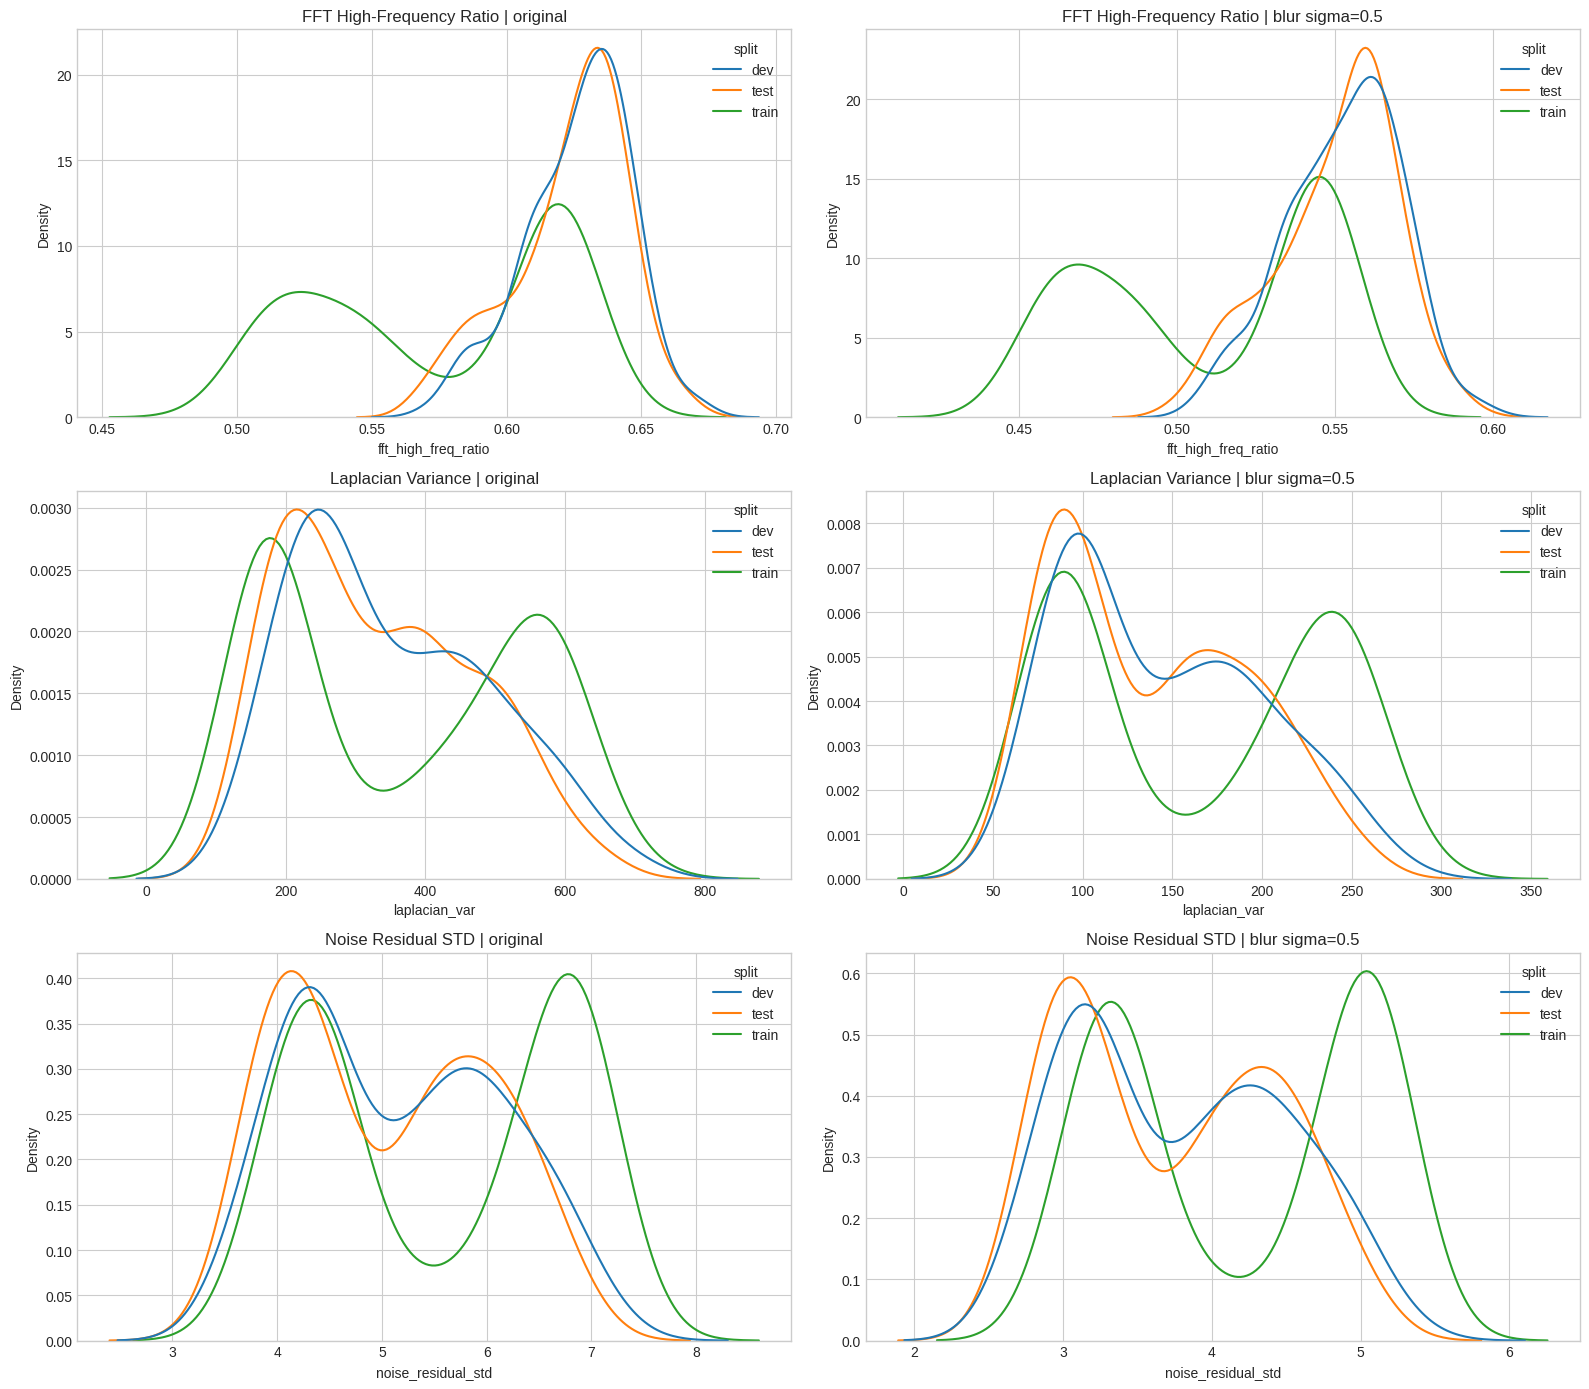

In [7]:
# Distribution check: 원본(sigma=0)과 best nonzero sigma의 분포를 비교하는 셀
compare_sigma_df = freq_df.query('sigma in [0.0, @best_nonzero_sigma]').copy()
compare_sigma_df['condition'] = compare_sigma_df['sigma'].map({0.0: 'original', best_nonzero_sigma: f'blur_sigma_{best_nonzero_sigma:g}'})

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
plot_specs = [
    ('fft_high_freq_ratio', 'FFT High-Frequency Ratio'),
    ('laplacian_var', 'Laplacian Variance'),
    ('noise_residual_std', 'Noise Residual STD'),
]

for row_idx, (metric, title) in enumerate(plot_specs):
    sigma0_df = compare_sigma_df.query('condition == "original"')
    sigmab_df = compare_sigma_df.loc[compare_sigma_df['condition'].eq(f'blur_sigma_{best_nonzero_sigma:g}')].copy()

    sns.kdeplot(
        data=sigma0_df,
        x=metric,
        hue='split',
        common_norm=False,
        ax=axes[row_idx, 0],
    )
    axes[row_idx, 0].set_title(f'{title} | original')

    sns.kdeplot(
        data=sigmab_df,
        x=metric,
        hue='split',
        common_norm=False,
        ax=axes[row_idx, 1],
    )
    axes[row_idx, 1].set_title(f'{title} | blur sigma={best_nonzero_sigma:g}')

plt.tight_layout()

summary_table = (
    compare_sigma_df.groupby(['condition', 'split', 'view'])[metric_cols + ['edge_density']]
    .agg(['mean', 'std', 'median'])
    .round(4)
)
display(summary_table)

,sample_id,view,orig_fft_high_freq_ratio,blur_fft_high_freq_ratio,orig_laplacian_var,blur_laplacian_var,orig_noise_residual_std,blur_noise_residual_std
0,TRAIN_0098,front,0.6144,0.5444,448.7307,207.8240,6.4286,4.8436
1,TRAIN_0406,front,0.6169,0.5387,657.9048,259.8433,6.9638,5.1255
2,TRAIN_0408,front,0.6215,0.5462,579.0761,247.9791,6.9190,5.1410
3,TRAIN_0634,front,0.6203,0.5449,548.0374,233.6923,6.7016,4.9766
4,TRAIN_0751,front,0.6243,0.5472,588.6447,246.4925,6.8565,5.0835
5,TRAIN_0098,top,0.5014,0.4537,136.5518,72.4761,3.9014,3.0433
6,TRAIN_0488,top,0.5119,0.4618,137.0449,72.3059,3.9146,3.0615
7,TRAIN_0729,top,0.5483,0.4870,199.6706,98.4137,4.5317,3.4434
8,TRAIN_0756,top,0.5474,0.4870,195.3909,96.5736,4.5029,3.4275
9,TRAIN_0931,top,0.5239,0.4702,176.3431,90.6928,4.3664,3.3702


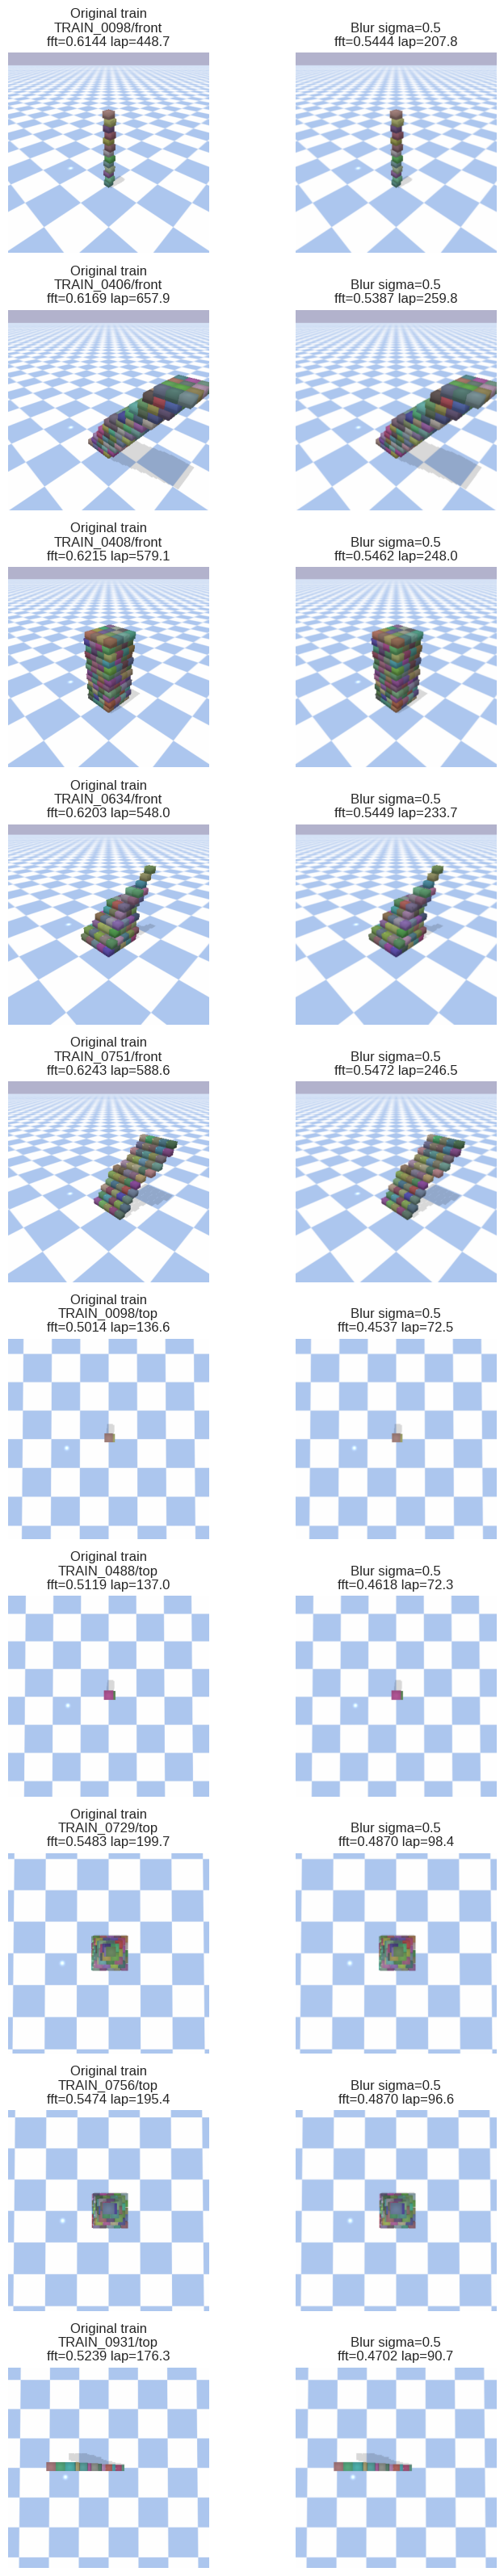

In [8]:
# Sample check: 10개 샘플을 원본과 best sigma blur로 비교하는 셀
def show_blur_examples(n_per_view: int = 5, seed: int = RANDOM_STATE) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    selected_rows = []

    for view in VIEWS:
        part = sampled_images.query('split == "train" and view == @view').copy()
        chosen_idx = rng.choice(part.index.to_numpy(), size=min(n_per_view, len(part)), replace=False)
        chosen = part.loc[chosen_idx].sort_values('sample_id').reset_index(drop=True)
        selected_rows.append(chosen)

    selected_df = pd.concat(selected_rows, ignore_index=True)

    fig, axes = plt.subplots(len(selected_df), 2, figsize=(8, 3.2 * len(selected_df)))
    if len(selected_df) == 1:
        axes = np.array([axes])

    summary_rows = []
    for ax_row, row in zip(axes, selected_df.itertuples(index=False)):
        original_rgb = read_rgb(Path(row.image_path))
        blurred_rgb = apply_gaussian_blur_rgb(original_rgb, best_nonzero_sigma)

        original_feat = extract_frequency_features(original_rgb)
        blurred_feat = extract_frequency_features(blurred_rgb)

        titles = [
            f'Original train\n{row.sample_id}/{row.view}\nfft={original_feat["fft_high_freq_ratio"]:.4f} lap={original_feat["laplacian_var"]:.1f}',
            f'Blur sigma={best_nonzero_sigma:g}\nfft={blurred_feat["fft_high_freq_ratio"]:.4f} lap={blurred_feat["laplacian_var"]:.1f}',
        ]

        for ax, img, title in zip(ax_row, [original_rgb, blurred_rgb], titles):
            ax.imshow(img)
            ax.set_title(title)
            ax.axis('off')

        summary_rows.append({
            'sample_id': row.sample_id,
            'view': row.view,
            'orig_fft_high_freq_ratio': original_feat['fft_high_freq_ratio'],
            'blur_fft_high_freq_ratio': blurred_feat['fft_high_freq_ratio'],
            'orig_laplacian_var': original_feat['laplacian_var'],
            'blur_laplacian_var': blurred_feat['laplacian_var'],
            'orig_noise_residual_std': original_feat['noise_residual_std'],
            'blur_noise_residual_std': blurred_feat['noise_residual_std'],
        })

    plt.tight_layout()
    return pd.DataFrame(summary_rows).round(4)


example_df = show_blur_examples(n_per_view=5)
display(example_df)

In [9]:
# Structure-only sigma sweep: segmentation된 구조물만 남겨서 주파수 분석하는 셀
structure_feature_rows = []
for sigma in SIGMAS:
    desc = f'Structure-only frequency | sigma={sigma}'
    for row in tqdm(list(sampled_images.itertuples(index=False)), desc=desc):
        rgb = read_rgb(Path(row.image_path))
        blurred_rgb = apply_gaussian_blur_rgb(rgb, sigma)
        structure_rgb, structure_mask = extract_structure_only_image(blurred_rgb)
        freq_stats = extract_frequency_features(structure_rgb)
        structure_feature_rows.append({
            'sigma': sigma,
            'split': row.split,
            'sample_id': row.sample_id,
            'view': row.view,
            'image_path': Path(row.image_path),
            'crop_h': int(structure_rgb.shape[0]),
            'crop_w': int(structure_rgb.shape[1]),
            'mask_area_ratio': float((structure_mask > 0).mean()) if structure_mask.size else 0.0,
            **freq_stats,
        })

structure_freq_df = pd.DataFrame(structure_feature_rows)
structure_freq_path = OUT_DIR / 'frequency_blur_sweep_structure_only.csv'
structure_freq_df.to_csv(structure_freq_path, index=False)
print('saved:', structure_freq_path)
structure_freq_df.head()

Structure-only frequency | sigma=0.0:   0%|          | 0/800 [00:00<?, ?it/s]

Structure-only frequency | sigma=0.5:   0%|          | 0/800 [00:00<?, ?it/s]

Structure-only frequency | sigma=1.0:   0%|          | 0/800 [00:00<?, ?it/s]

Structure-only frequency | sigma=1.5:   0%|          | 0/800 [00:00<?, ?it/s]

Structure-only frequency | sigma=2.0:   0%|          | 0/800 [00:00<?, ?it/s]

saved: /media/hdd0/whyz/structure-stability/outputs/eda_preprocessing/frequency_blur_sweep_structure_only.csv


,sigma,split,sample_id,view,image_path,crop_h,crop_w,mask_area_ratio,fft_high_freq_ratio,laplacian_var,noise_residual_std,edge_density
0,0.0,dev,DEV_001,front,/media/hdd0/whyz/structure-stability/data/dev/...,384,384,0.016703,0.637002,327.098755,5.252008,0.050720
1,0.0,dev,DEV_001,top,/media/hdd0/whyz/structure-stability/data/dev/...,155,105,0.347773,0.457032,72.058914,2.267935,0.002458
2,0.0,dev,DEV_002,front,/media/hdd0/whyz/structure-stability/data/dev/...,269,197,0.304606,0.732598,301.870148,4.300670,0.017172
3,0.0,dev,DEV_002,top,/media/hdd0/whyz/structure-stability/data/dev/...,239,109,0.562243,0.708475,509.636322,6.021626,0.036313
4,0.0,dev,DEV_003,front,/media/hdd0/whyz/structure-stability/data/dev/...,226,127,0.347258,0.727072,697.328125,6.564575,0.026165


,sigma,view,metric,train_vs_dev,train_vs_test,avg_gap
0,0.0,front,fft_high_freq_ratio,0.0792,0.0353,0.0572
1,0.0,front,laplacian_var,0.1243,0.0753,0.0998
2,0.0,front,noise_residual_std,0.0845,0.0500,0.0672
3,0.0,top,fft_high_freq_ratio,0.0974,0.0748,0.0861
4,0.0,top,laplacian_var,0.0653,0.0530,0.0591
5,0.0,top,noise_residual_std,0.0700,0.0843,0.0771
6,0.5,front,fft_high_freq_ratio,0.0668,0.0349,0.0508
7,0.5,front,laplacian_var,0.1124,0.0799,0.0962
8,0.5,front,noise_residual_std,0.0721,0.0519,0.0620
9,0.5,top,fft_high_freq_ratio,0.0669,0.0809,0.0739


,sigma,train_vs_dev,train_vs_test,avg_gap
0,0.0,0.0868,0.0621,0.0744
1,0.5,0.1160,0.1139,0.1149
4,2.0,0.1249,0.1254,0.1251
2,1.0,0.1412,0.1219,0.1316
3,1.5,0.1382,0.1259,0.1321


{'best_structure_sigma': 0.0, 'best_structure_nonzero_sigma': 0.5}


,sigma,full_image_avg_gap,structure_only_avg_gap
0,0.0,0.2385,0.0744
1,0.5,0.2611,0.1149
4,1.0,0.3034,0.1316
2,1.5,0.2662,0.1321
3,2.0,0.2979,0.1251


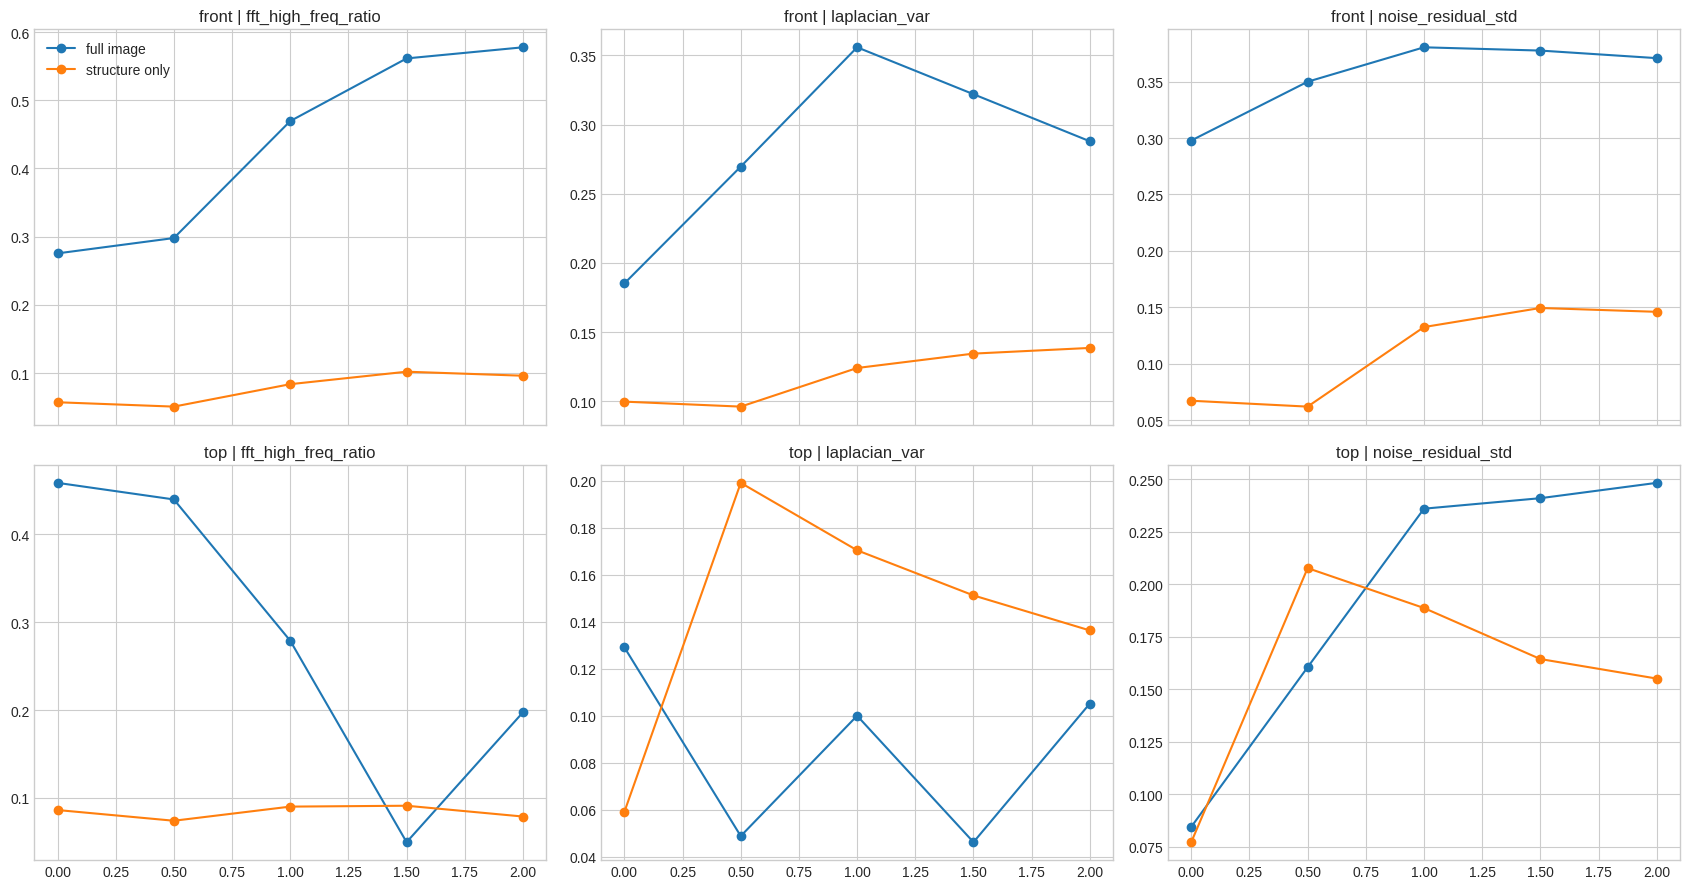

In [10]:
# Structure-only summary: 체커보드 제거 후 sigma별 split gap을 비교하는 셀
structure_distance_rows = []
for sigma in SIGMAS:
    sigma_df = structure_freq_df.query('sigma == @sigma')
    for view in VIEWS:
        for metric in metric_cols:
            train_vals = sigma_df.query('split == "train" and view == @view')[metric].to_numpy()
            dev_vals = sigma_df.query('split == "dev" and view == @view')[metric].to_numpy()
            test_vals = sigma_df.query('split == "test" and view == @view')[metric].to_numpy()
            structure_distance_rows.append({
                'sigma': sigma,
                'view': view,
                'metric': metric,
                'train_vs_dev': cdf_distance(train_vals, dev_vals),
                'train_vs_test': cdf_distance(train_vals, test_vals),
                'avg_gap': np.mean([
                    cdf_distance(train_vals, dev_vals),
                    cdf_distance(train_vals, test_vals),
                ]),
            })

structure_distance_df = pd.DataFrame(structure_distance_rows).round(4)
display(structure_distance_df)

structure_sigma_score_df = (
    structure_distance_df.groupby('sigma')[['train_vs_dev', 'train_vs_test', 'avg_gap']]
    .mean()
    .round(4)
    .reset_index()
    .sort_values('avg_gap')
)
display(structure_sigma_score_df)

best_structure_sigma = float(structure_sigma_score_df.iloc[0]['sigma'])
best_structure_nonzero_sigma = float(structure_sigma_score_df.query('sigma > 0').iloc[0]['sigma']) if len(structure_sigma_score_df.query('sigma > 0')) else best_structure_sigma
print({'best_structure_sigma': best_structure_sigma, 'best_structure_nonzero_sigma': best_structure_nonzero_sigma})

comparison_summary_df = (
    sigma_score_df[['sigma', 'avg_gap']]
    .rename(columns={'avg_gap': 'full_image_avg_gap'})
    .merge(
        structure_sigma_score_df[['sigma', 'avg_gap']].rename(columns={'avg_gap': 'structure_only_avg_gap'}),
        on='sigma',
        how='inner',
    )
    .sort_values('sigma')
)
display(comparison_summary_df)

fig, axes = plt.subplots(2, 3, figsize=(17, 9), sharex=True)
for idx, metric in enumerate(metric_cols):
    for row_idx, view in enumerate(VIEWS):
        ax = axes[row_idx, idx]
        full_part = distance_df.query('view == @view and metric == @metric')
        struct_part = structure_distance_df.query('view == @view and metric == @metric')
        ax.plot(full_part['sigma'], full_part['avg_gap'], marker='o', label='full image')
        ax.plot(struct_part['sigma'], struct_part['avg_gap'], marker='o', label='structure only')
        ax.set_title(f'{view} | {metric}')
        if idx == 0 and row_idx == 0:
            ax.legend()

plt.tight_layout()

,sample_id,view,mask_area_ratio,crop_h,crop_w,orig_fft_high_freq_ratio,structure_fft_high_freq_ratio,orig_laplacian_var,structure_laplacian_var
0,TRAIN_0098,front,0.0211,384,384,0.6144,0.5444,448.7307,207.8240
1,TRAIN_0649,front,0.0575,209,125,0.6980,0.6558,345.4626,181.4572
2,TRAIN_0758,front,0.0171,146,59,0.6156,0.5850,239.2289,151.5187
3,TRAIN_0095,top,0.0230,67,111,0.6754,0.6833,521.0109,613.6055
4,TRAIN_0708,top,0.0343,95,89,0.6934,0.6936,772.2161,934.8570
5,TRAIN_0804,top,0.0039,384,384,0.5268,0.4720,145.9278,75.8274


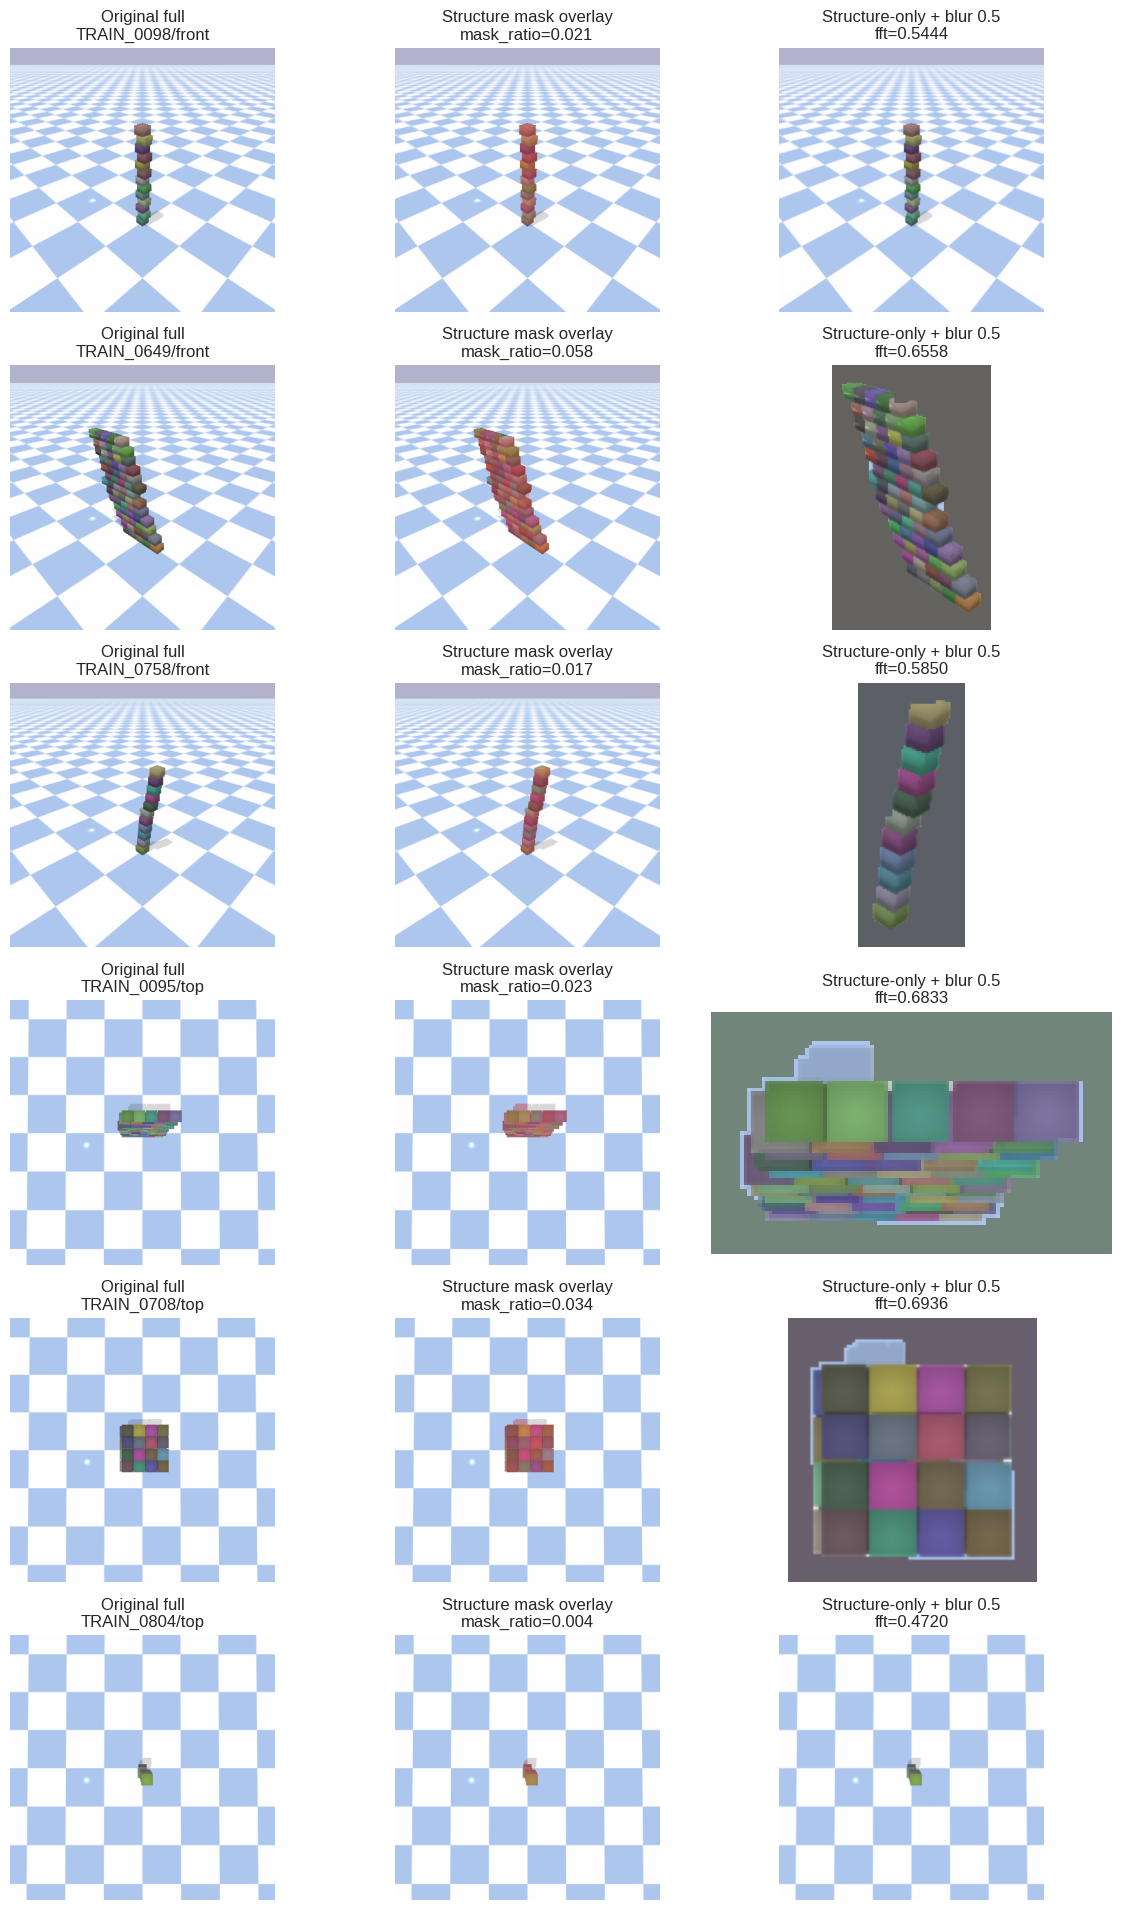

In [11]:
# Structure-only sample check: segmentation된 구조물 기준 blur 결과를 보는 셀
def show_structure_frequency_examples(n_per_view: int = 3, seed: int = RANDOM_STATE) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    selected_rows = []
    for view in VIEWS:
        part = sampled_images.query('split == "train" and view == @view').copy()
        chosen_idx = rng.choice(part.index.to_numpy(), size=min(n_per_view, len(part)), replace=False)
        selected_rows.append(part.loc[chosen_idx].sort_values('sample_id').reset_index(drop=True))

    selected_df = pd.concat(selected_rows, ignore_index=True)
    fig, axes = plt.subplots(len(selected_df), 3, figsize=(12, 3.2 * len(selected_df)))
    if len(selected_df) == 1:
        axes = np.array([axes])

    summary_rows = []
    for ax_row, row in zip(axes, selected_df.itertuples(index=False)):
        original_rgb = read_rgb(Path(row.image_path))
        mask = estimate_structure_mask(original_rgb)
        orig_structure_rgb, orig_structure_mask = extract_structure_only_image(original_rgb)
        blurred_rgb = apply_gaussian_blur_rgb(original_rgb, best_structure_nonzero_sigma)
        structure_rgb, structure_mask = extract_structure_only_image(blurred_rgb)

        overlay_rgb = original_rgb.copy()
        overlay_rgb[mask > 0] = (0.65 * overlay_rgb[mask > 0] + 0.35 * np.array([255, 80, 80])).astype(np.uint8)

        orig_feat = extract_frequency_features(orig_structure_rgb)
        crop_feat = extract_frequency_features(structure_rgb)

        titles = [
            f'Original full\n{row.sample_id}/{row.view}',
            f'Structure mask overlay\nmask_ratio={(mask > 0).mean():.3f}',
            f'Structure-only + blur {best_structure_nonzero_sigma:g}\nfft={crop_feat["fft_high_freq_ratio"]:.4f}',
        ]

        for ax, img, title in zip(ax_row, [original_rgb, overlay_rgb, structure_rgb], titles):
            ax.imshow(img)
            ax.set_title(title)
            ax.axis('off')

        summary_rows.append({
            'sample_id': row.sample_id,
            'view': row.view,
            'mask_area_ratio': float((mask > 0).mean()),
            'crop_h': int(structure_rgb.shape[0]),
            'crop_w': int(structure_rgb.shape[1]),
            'orig_fft_high_freq_ratio': orig_feat['fft_high_freq_ratio'],
            'structure_fft_high_freq_ratio': crop_feat['fft_high_freq_ratio'],
            'orig_laplacian_var': orig_feat['laplacian_var'],
            'structure_laplacian_var': crop_feat['laplacian_var'],
        })

    plt.tight_layout()
    return pd.DataFrame(summary_rows).round(4)


structure_example_df = show_structure_frequency_examples(n_per_view=3)
display(structure_example_df)

In [12]:
# Resize degradation setup: downscale-upscale 전처리 정의 셀
SCALES = [1.0, 0.85, 0.7, 0.55, 0.4]


def apply_resize_degradation_rgb(rgb: np.ndarray, scale: float) -> np.ndarray:
    if scale >= 0.999:
        return rgb.copy()
    h, w = rgb.shape[:2]
    down_h = max(24, int(round(h * scale)))
    down_w = max(24, int(round(w * scale)))
    down = cv2.resize(rgb, (down_w, down_h), interpolation=cv2.INTER_AREA)
    up = cv2.resize(down, (w, h), interpolation=cv2.INTER_LINEAR)
    return up


print({'scales': SCALES})

{'scales': [1.0, 0.85, 0.7, 0.55, 0.4]}


In [13]:
# Structure-only resize sweep: segmentation된 구조물만 남겨 resize-down-up을 비교하는 셀
resize_feature_rows = []
for scale in SCALES:
    desc = f'Structure-only resize | scale={scale}'
    for row in tqdm(list(sampled_images.itertuples(index=False)), desc=desc):
        rgb = read_rgb(Path(row.image_path))
        resized_rgb = apply_resize_degradation_rgb(rgb, scale)
        structure_rgb, structure_mask = extract_structure_only_image(resized_rgb)
        freq_stats = extract_frequency_features(structure_rgb)
        resize_feature_rows.append({
            'scale': scale,
            'split': row.split,
            'sample_id': row.sample_id,
            'view': row.view,
            'image_path': Path(row.image_path),
            'crop_h': int(structure_rgb.shape[0]),
            'crop_w': int(structure_rgb.shape[1]),
            'mask_area_ratio': float((structure_mask > 0).mean()) if structure_mask.size else 0.0,
            **freq_stats,
        })

resize_freq_df = pd.DataFrame(resize_feature_rows)
resize_freq_path = OUT_DIR / 'frequency_resize_sweep_structure_only.csv'
resize_freq_df.to_csv(resize_freq_path, index=False)
print('saved:', resize_freq_path)
resize_freq_df.head()

Structure-only resize | scale=1.0:   0%|          | 0/800 [00:00<?, ?it/s]

Structure-only resize | scale=0.85:   0%|          | 0/800 [00:00<?, ?it/s]

Structure-only resize | scale=0.7:   0%|          | 0/800 [00:00<?, ?it/s]

Structure-only resize | scale=0.55:   0%|          | 0/800 [00:00<?, ?it/s]

Structure-only resize | scale=0.4:   0%|          | 0/800 [00:00<?, ?it/s]

saved: /media/hdd0/whyz/structure-stability/outputs/eda_preprocessing/frequency_resize_sweep_structure_only.csv


,scale,split,sample_id,view,image_path,crop_h,crop_w,mask_area_ratio,fft_high_freq_ratio,laplacian_var,noise_residual_std,edge_density
0,1.0,dev,DEV_001,front,/media/hdd0/whyz/structure-stability/data/dev/...,384,384,0.016703,0.637002,327.098755,5.252008,0.050720
1,1.0,dev,DEV_001,top,/media/hdd0/whyz/structure-stability/data/dev/...,155,105,0.347773,0.457032,72.058914,2.267935,0.002458
2,1.0,dev,DEV_002,front,/media/hdd0/whyz/structure-stability/data/dev/...,269,197,0.304606,0.732598,301.870148,4.300670,0.017172
3,1.0,dev,DEV_002,top,/media/hdd0/whyz/structure-stability/data/dev/...,239,109,0.562243,0.708475,509.636322,6.021626,0.036313
4,1.0,dev,DEV_003,front,/media/hdd0/whyz/structure-stability/data/dev/...,226,127,0.347258,0.727072,697.328125,6.564575,0.026165


,scale,view,metric,train_vs_dev,train_vs_test,avg_gap
0,1.00,front,fft_high_freq_ratio,0.0792,0.0353,0.0572
1,1.00,front,laplacian_var,0.1243,0.0753,0.0998
2,1.00,front,noise_residual_std,0.0845,0.0500,0.0672
3,1.00,top,fft_high_freq_ratio,0.0974,0.0748,0.0861
4,1.00,top,laplacian_var,0.0653,0.0530,0.0591
5,1.00,top,noise_residual_std,0.0700,0.0843,0.0771
6,0.85,front,fft_high_freq_ratio,0.0682,0.0506,0.0594
7,0.85,front,laplacian_var,0.1412,0.1225,0.1319
8,0.85,front,noise_residual_std,0.1095,0.0891,0.0993
9,0.85,top,fft_high_freq_ratio,0.0730,0.0828,0.0779


,scale,train_vs_dev,train_vs_test,avg_gap
4,1.00,0.0868,0.0621,0.0744
3,0.85,0.1291,0.1238,0.1265
1,0.55,0.1325,0.1281,0.1303
2,0.70,0.1411,0.1201,0.1306
0,0.40,0.1424,0.1307,0.1365


{'best_resize_scale': 1.0, 'best_resize_nontrivial_scale': 0.85}


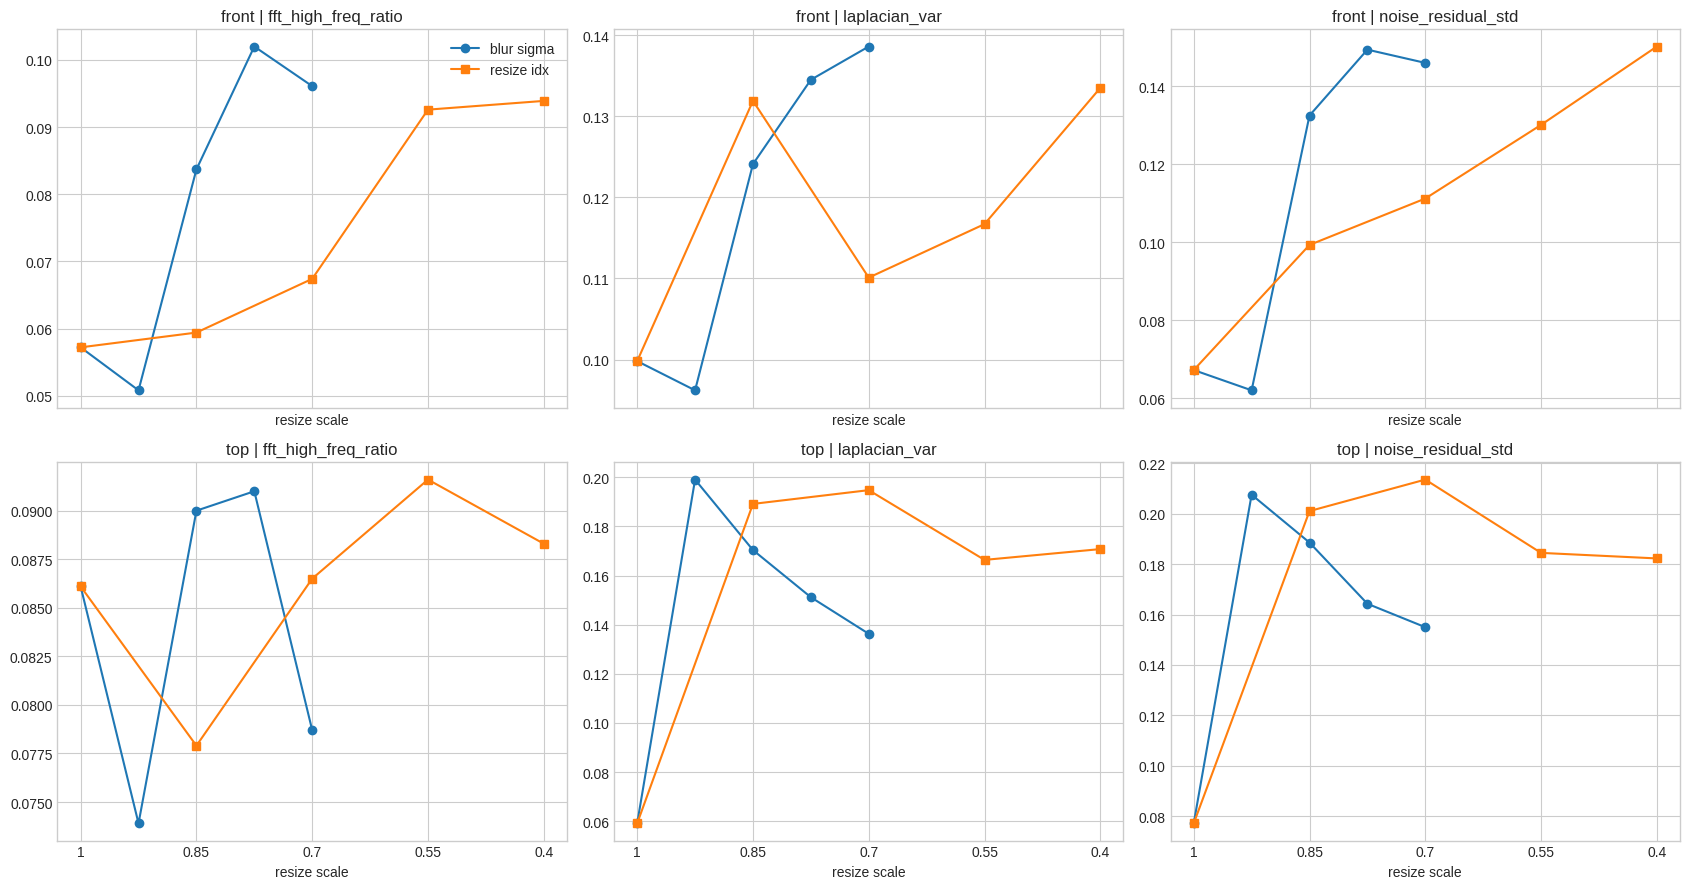

In [14]:
# Structure-only resize summary: scale별 split gap 비교 셀
resize_distance_rows = []
for scale in SCALES:
    scale_df = resize_freq_df.query('scale == @scale')
    for view in VIEWS:
        for metric in metric_cols:
            train_vals = scale_df.query('split == "train" and view == @view')[metric].to_numpy()
            dev_vals = scale_df.query('split == "dev" and view == @view')[metric].to_numpy()
            test_vals = scale_df.query('split == "test" and view == @view')[metric].to_numpy()
            resize_distance_rows.append({
                'scale': scale,
                'view': view,
                'metric': metric,
                'train_vs_dev': cdf_distance(train_vals, dev_vals),
                'train_vs_test': cdf_distance(train_vals, test_vals),
                'avg_gap': np.mean([
                    cdf_distance(train_vals, dev_vals),
                    cdf_distance(train_vals, test_vals),
                ]),
            })

resize_distance_df = pd.DataFrame(resize_distance_rows).round(4)
display(resize_distance_df)

resize_scale_score_df = (
    resize_distance_df.groupby('scale')[['train_vs_dev', 'train_vs_test', 'avg_gap']]
    .mean()
    .round(4)
    .reset_index()
    .sort_values('avg_gap')
)
display(resize_scale_score_df)

best_resize_scale = float(resize_scale_score_df.iloc[0]['scale'])
best_resize_nontrivial_scale = float(resize_scale_score_df.query('scale < 0.999').iloc[0]['scale']) if len(resize_scale_score_df.query('scale < 0.999')) else best_resize_scale
print({'best_resize_scale': best_resize_scale, 'best_resize_nontrivial_scale': best_resize_nontrivial_scale})

fig, axes = plt.subplots(2, 3, figsize=(17, 9), sharex=True)
for idx, metric in enumerate(metric_cols):
    for row_idx, view in enumerate(VIEWS):
        ax = axes[row_idx, idx]
        blur_part = structure_distance_df.query('view == @view and metric == @metric')
        resize_part = resize_distance_df.query('view == @view and metric == @metric')
        ax.plot(blur_part['sigma'], blur_part['avg_gap'], marker='o', label='blur sigma')
        ax.plot(np.arange(len(resize_part)), resize_part['avg_gap'], marker='s', label='resize idx')
        ax.set_title(f'{view} | {metric}')
        ax.set_xticks(np.arange(len(resize_part)))
        ax.set_xticklabels([f'{s:g}' for s in resize_part['scale']])
        ax.set_xlabel('resize scale')
        if idx == 0 and row_idx == 0:
            ax.legend()

plt.tight_layout()

,sample_id,view,best_resize_nontrivial_scale,mask_area_ratio,orig_fft_high_freq_ratio,resize_fft_high_freq_ratio,orig_laplacian_var,resize_laplacian_var,orig_noise_residual_std,resize_noise_residual_std
0,TRAIN_0098,front,0.85,0.0207,0.6144,0.4800,448.7307,107.2105,6.4286,3.7709
1,TRAIN_0649,front,0.85,0.3266,0.6980,0.6481,345.4626,172.1091,4.6820,3.6126
2,TRAIN_0758,front,0.85,0.2949,0.6156,0.6132,239.2289,222.5177,3.8867,3.9364
3,TRAIN_0095,top,0.85,0.4764,0.6754,0.6544,521.0109,437.2682,6.4650,6.1911
4,TRAIN_0708,top,0.85,0.6155,0.6934,0.6805,772.2161,819.9885,6.9195,8.6877
5,TRAIN_0804,top,0.85,0.0045,0.5268,0.4336,145.9278,43.8924,3.9807,2.4948


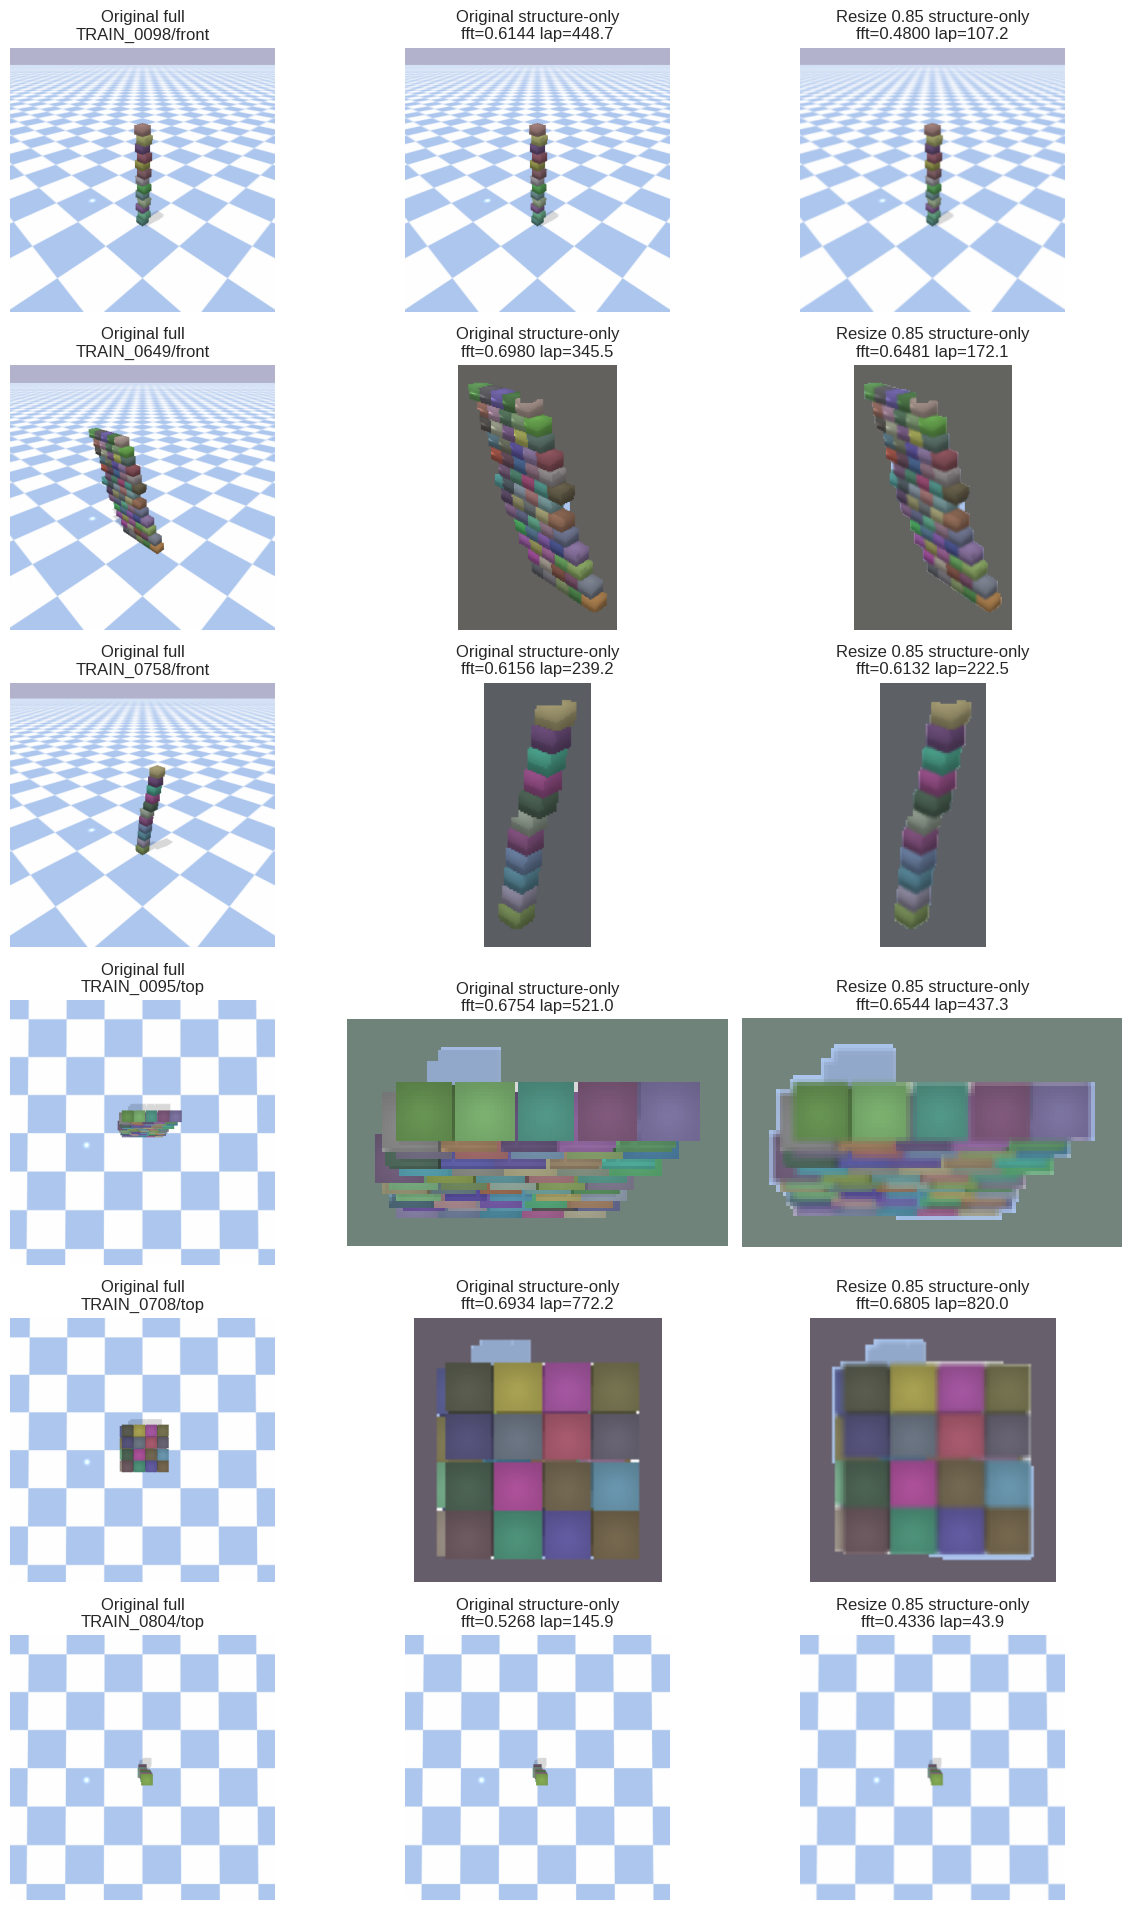

In [15]:
# Resize sample check: segmentation된 구조물 기준 샘플 시각화 셀
def show_resize_frequency_examples(n_per_view: int = 3, seed: int = RANDOM_STATE) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    selected_rows = []
    for view in VIEWS:
        part = sampled_images.query('split == "train" and view == @view').copy()
        chosen_idx = rng.choice(part.index.to_numpy(), size=min(n_per_view, len(part)), replace=False)
        selected_rows.append(part.loc[chosen_idx].sort_values('sample_id').reset_index(drop=True))

    selected_df = pd.concat(selected_rows, ignore_index=True)
    fig, axes = plt.subplots(len(selected_df), 3, figsize=(12, 3.2 * len(selected_df)))
    if len(selected_df) == 1:
        axes = np.array([axes])

    summary_rows = []
    for ax_row, row in zip(axes, selected_df.itertuples(index=False)):
        original_rgb = read_rgb(Path(row.image_path))
        degraded_rgb = apply_resize_degradation_rgb(original_rgb, best_resize_nontrivial_scale)
        orig_structure_rgb, _ = extract_structure_only_image(original_rgb)
        degraded_structure_rgb, degraded_structure_mask = extract_structure_only_image(degraded_rgb)

        orig_feat = extract_frequency_features(orig_structure_rgb)
        degraded_feat = extract_frequency_features(degraded_structure_rgb)

        titles = [
            f'Original full\n{row.sample_id}/{row.view}',
            f'Original structure-only\nfft={orig_feat["fft_high_freq_ratio"]:.4f} lap={orig_feat["laplacian_var"]:.1f}',
            f'Resize {best_resize_nontrivial_scale:g} structure-only\nfft={degraded_feat["fft_high_freq_ratio"]:.4f} lap={degraded_feat["laplacian_var"]:.1f}',
        ]

        for ax, img, title in zip(ax_row, [original_rgb, orig_structure_rgb, degraded_structure_rgb], titles):
            ax.imshow(img)
            ax.set_title(title)
            ax.axis('off')

        summary_rows.append({
            'sample_id': row.sample_id,
            'view': row.view,
            'best_resize_nontrivial_scale': best_resize_nontrivial_scale,
            'mask_area_ratio': float((degraded_structure_mask > 0).mean()) if degraded_structure_mask.size else 0.0,
            'orig_fft_high_freq_ratio': orig_feat['fft_high_freq_ratio'],
            'resize_fft_high_freq_ratio': degraded_feat['fft_high_freq_ratio'],
            'orig_laplacian_var': orig_feat['laplacian_var'],
            'resize_laplacian_var': degraded_feat['laplacian_var'],
            'orig_noise_residual_std': orig_feat['noise_residual_std'],
            'resize_noise_residual_std': degraded_feat['noise_residual_std'],
        })

    plt.tight_layout()
    return pd.DataFrame(summary_rows).round(4)


resize_example_df = show_resize_frequency_examples(n_per_view=3)
display(resize_example_df)